In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

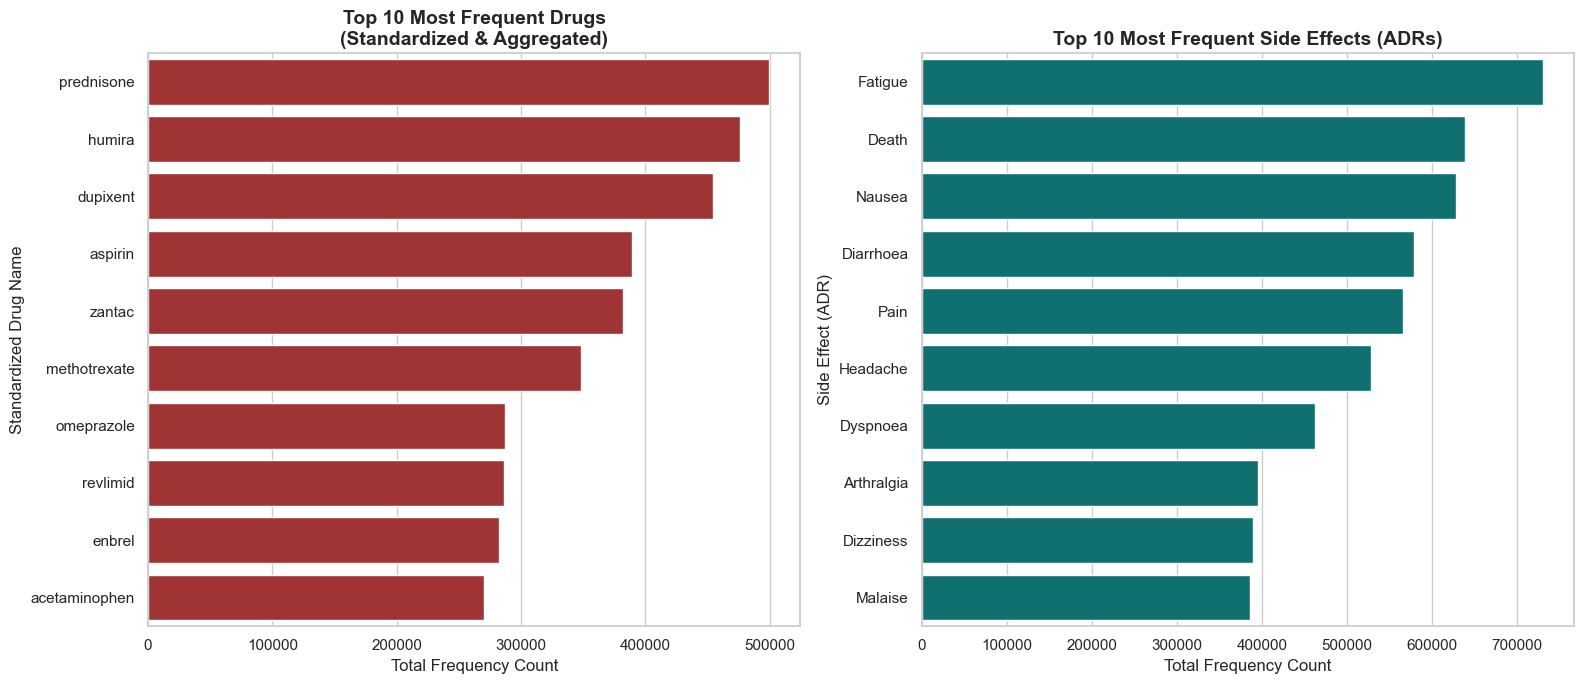

In [3]:

# Load data
mapping_df = pd.read_csv('/Users/duncanpark/10-faers-foundation-model/data/drug_name_mapping_updated.csv')
freq_df = pd.read_csv('/Users/duncanpark/10-faers-foundation-model/frequent_drugs_ADRs.csv')

# Strip whitespaces
freq_df['Drug_clean'] = freq_df['Drug'].astype(str).str.strip()
mapping_df['messy_name_clean'] = mapping_df['messy_name'].astype(str).str.strip()

# Merge drug frequencies with the mapping lookup table
merged_drugs = pd.merge(
    freq_df[['Drug_clean', 'Frequency']], 
    mapping_df[['messy_name_clean', 'standardized_name']], 
    left_on='Drug_clean', 
    right_on='messy_name_clean', 
    how='left'
)

# If a drug wasn't in mapping file, keep its original cleaned name
merged_drugs['standardized_name'] = merged_drugs['standardized_name'].fillna(merged_drugs['Drug_clean'])

# Aggregate the counts by the newly standardized names
final_drug_counts = (
    merged_drugs.groupby('standardized_name')['Frequency']
    .sum()
    .reset_index()
    .sort_values(by='Frequency', ascending=False)
    .reset_index(drop=True)
)
final_drug_counts.columns = ['Standardized_Drug', 'True_Frequency']

# Save the consolidated drug frequencies to a new CSV
final_drug_counts.to_csv('true_frequent_drugs.csv', index=False)

# Separate out the independent ADR (Side Effects) list
adr_df = freq_df[['ADR', 'Frequency.1']].dropna().copy()
adr_df.columns = ['ADR', 'Frequency']
adr_df['Frequency'] = adr_df['Frequency'].astype(int)

# Generate side-by-side descriptive plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 10 Standardized Drugs
sns.barplot(
    x='True_Frequency', 
    y='Standardized_Drug', 
    data=final_drug_counts.head(10), 
    color = 'firebrick',
    ax=axes[0]
)
axes[0].set_title('Top 10 Most Frequent Drugs\n(Standardized & Aggregated)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Frequency Count', fontsize=12)
axes[0].set_ylabel('Standardized Drug Name', fontsize=12)

# Top 10 Side Effects (ADRs)
sns.barplot(
    x='Frequency', 
    y='ADR', 
    data=adr_df.head(10), 
    color = 'teal',
    ax=axes[1]
)
axes[1].set_title('Top 10 Most Frequent Side Effects (ADRs)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Frequency Count', fontsize=12)
axes[1].set_ylabel('Side Effect (ADR)', fontsize=12)

plt.tight_layout()
plt.savefig('top_drugs_and_adrs.png', dpi=300)